# 1. Entendimento da Base de Dados

O dataset contém informações clínicas e demográficas de pacientes diabéticos com o objetivo de prever readmissão hospitalar.

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd


In [33]:
df = pd.read_csv("../data/raw/hospital_readmissions.csv")

df.shape

(25000, 17)

In [34]:
pd.set_option('display.max_rows', None)

# Informações sobre o DataFrame, incluindo o número de entradas, colunas, tipos de dados e uso de memória. Ele é útil para obter uma visão geral rápida do conteúdo do DataFrame.

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                25000 non-null  str  
 1   time_in_hospital   25000 non-null  int64
 2   n_lab_procedures   25000 non-null  int64
 3   n_procedures       25000 non-null  int64
 4   n_medications      25000 non-null  int64
 5   n_outpatient       25000 non-null  int64
 6   n_inpatient        25000 non-null  int64
 7   n_emergency        25000 non-null  int64
 8   medical_specialty  25000 non-null  str  
 9   diag_1             25000 non-null  str  
 10  diag_2             25000 non-null  str  
 11  diag_3             25000 non-null  str  
 12  glucose_test       25000 non-null  str  
 13  A1Ctest            25000 non-null  str  
 14  change             25000 non-null  str  
 15  diabetes_med       25000 non-null  str  
 16  readmitted         25000 non-null  str  
dtypes: int64(7), str(10)
me

In [36]:
contagem = df['readmitted'].value_counts()
percentual = df['readmitted'].value_counts(normalize=True) * 100
resultado = pd.DataFrame({'Contagem': contagem, 'Percentual': percentual})
resultado

,Contagem,Percentual
readmitted,,
no,13246,52.984
yes,11754,47.016


# Hipótese 1: Quantidade de dias nos hospitais influencia a probabilidade de readmissão.


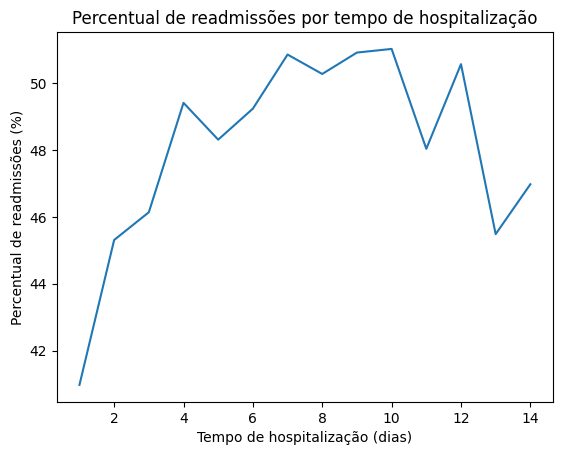

In [37]:
dias = df.groupby('time_in_hospital')['readmitted'].value_counts().unstack().fillna(0)
percentual = dias.div(dias.sum(axis=1), axis=0) * 100
dias
percentual
x = dias.index
y = percentual.yes
plt.plot(x, y)
plt.title('Percentual de readmissões por tempo de hospitalização')
plt.xlabel('Tempo de hospitalização (dias)')
plt.ylabel('Percentual de readmissões (%)')
plt.show()

# Resultados observados:
- A taxa de readmissão apresentou tendência de crescimento conforme o tempo de internação aumentou.
- Os maiores percentuais de readmissão foram observados entre 7 e 10 dias de hospitalização.
- Após esse período, a taxa de readmissão apresentou oscilações, sem manter um crescimento consistente.
Limitações da análise:
- O número de pacientes diminui significativamente para tempos de internação mais elevados (11 a 14 dias).
- Dessa forma, as estimativas para esses grupos possuem menor robustez estatística.
- São necessárias análises complementares para confirmar a força dessa relação.
Conclusão preliminar:
Existe evidência inicial de que pacientes com maior tempo de internação apresentam maior probabilidade de readmissão hospitalar, com um pico observado entre 7 e 10 dias. No entanto, a relação não é linear e requer investigação adicional para entender os fatores subjacentes.

<!-- Hipótese 1: O tempo de internação influencia a probabilidade de readmissão.
Resultados observados:
- A taxa de readmissão apresentou tendência de crescimento conforme o tempo de internação aumentou.
- Os maiores percentuais de readmissão foram observados entre 7 e 10 dias de hospitalização.
- Após esse período, a taxa de readmissão apresentou oscilações, sem manter um crescimento consistente.
Limitações da análise:
- O número de pacientes diminui significativamente para tempos de internação mais elevados (11 a 14 dias).
- Dessa forma, as estimativas para esses grupos possuem menor robustez estatística.
- São necessárias análises complementares para confirmar a força dessa relação.
Conclusão preliminar:
Existe evidência inicial de que pacientes com maior tempo de internação apresentam maior probabilidade de readmissão hospitalar, com um pico observado entre 7 e 10 dias. No entanto, a relação não é linear e requer investigação adicional para entender os fatores subjacentes. 
 -->

# Hipótese 2: Pacientes com histórico de internação anteriores possuem maior probabilidade de readmissão.


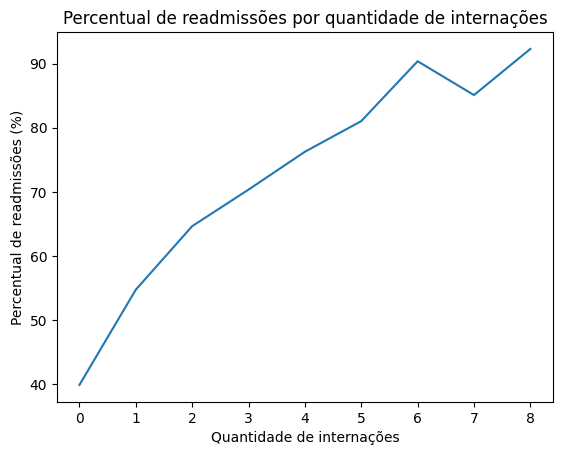

In [38]:
qtde_internacoes = df.groupby('n_inpatient')['readmitted'].value_counts().unstack().fillna(0)
percentual = qtde_internacoes.div(qtde_internacoes.sum(axis=1), axis=0) * 100
qtde_internacoes_filtrado = qtde_internacoes.loc[:8]
percentual_filtrado = percentual.loc[:8]
x = qtde_internacoes_filtrado.index
y = percentual_filtrado.yes
plt.plot(x, y)
plt.title('Percentual de readmissões por quantidade de internações')
plt.xlabel('Quantidade de internações')
plt.ylabel('Percentual de readmissões (%)')
plt.show()


# Resultado observado: - Foi identificada uma forte relação positiva entre o número de internações prévias e a taxa de readmissão.
- Pacientes sem histórico de internação apresentaram taxa de readmissão de aproximadamente 40%.
- A taxa de readmissão aumentou progressivamente à medida que o número de internações anteriores cresceu.
- Pacientes com cinco internações prévias apresentaram taxa superior a 80%.

# Limitações:
- Grupos com valores muito altos de números de internações possuem poucos pacientes observados e devem ser interpretados com cautela.
# Conclusão preliminar:
O histórico de internações anteriores demonstra forte potencial preditivo e pode ser uma das variáveis mais relevantes para o modelo de classificação.

# Tratamento de Outliers Estatísticos

Foram removidos grupos com mais de 9 internações prévias devido ao baixo número de pacientes observados, o que poderia gerar percentuais instáveis e interpretações equivocadas.

# Hipótese 3: Existe associação entre a quantidade de medicamentos administrados e a probabilidade de readmissão hospitalar.


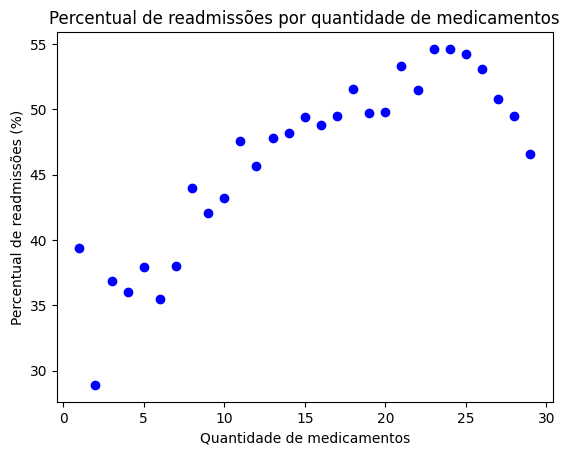

In [39]:
medicamentos = df.groupby('n_medications',)['readmitted'].value_counts().unstack().fillna(0)
medicamentos = medicamentos.reindex(columns=sorted(medicamentos.columns), fill_value=0)
pd.set_option('display.max_rows', None)
percentual = medicamentos.div(medicamentos.sum(axis=1), axis=0) * 100
medicamentos_filtrado = medicamentos[medicamentos.index < 30]
x = medicamentos_filtrado.index
y = percentual.loc[medicamentos_filtrado.index].yes
plt.scatter(x, y, color='blue', marker='o')
plt.title('Percentual de readmissões por quantidade de medicamentos')
plt.xlabel('Quantidade de medicamentos')
plt.ylabel('Percentual de readmissões (%)')
plt.show()


# Resultados observados:
- Foi identificada uma tendência de aumento da taxa de readmissão conforme cresce a quantidade de medicamentos administrados.
- Pacientes que receberam até aproximadamente 10 medicamentos apresentaram taxas de readmissão inferiores a 45%.
- A partir de aproximadamente 18 a 25 medicamentos, a taxa de readmissão ultrapassou 50% em diversos grupos.
Limitações:
- Os grupos com grande quantidade de medicamentos possuem poucos pacientes.
- Isso gera maior variabilidade nas estimativas observadas.
# Conclusão preliminar:
A quantidade de medicamentos demonstra potencial relação com a readmissão hospitalar, embora o efeito observado seja menos pronunciado do que o identificado para o histórico de internações anteriores.

# Hipótese 4: Indicadores relacionados ao diabetes estão associados a uma maior probabilidade de readmissão hospitalar.
Variáveis investigadas:
A1Ctest (Hemoglobina Glicada, analisa diabetes a longo prazo)
glucose_test (Teste de glicose atual)
diabetes_med (diagnóstico de diabetes)
change (mudança de remédios)



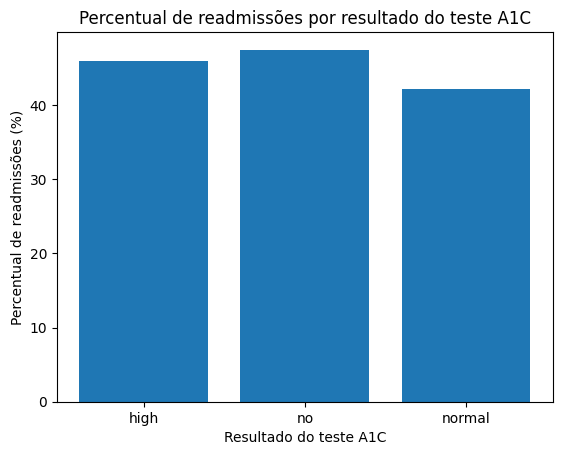

In [40]:
teste = df.groupby(['A1Ctest'])['readmitted'].value_counts().unstack().fillna(0)
percentual = teste.div(teste.sum(axis=1), axis=0) * 100
teste
percentual
x = teste.index
y = percentual.yes
plt.bar(x, y)
plt.title('Percentual de readmissões por resultado do teste A1C')
plt.xlabel('Resultado do teste A1C')
plt.ylabel('Percentual de readmissões (%)')
plt.show()

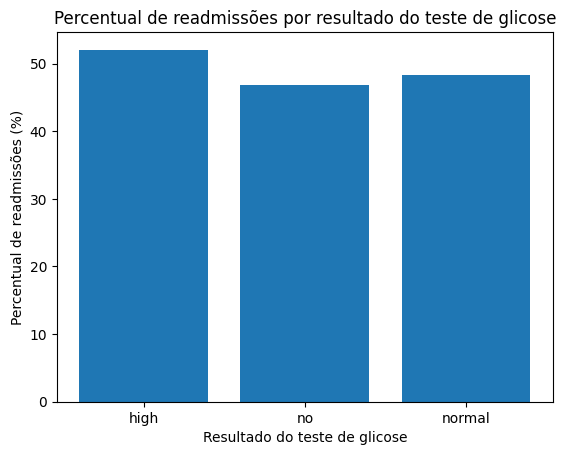

In [41]:
teste_glicose = df.groupby(['glucose_test'])['readmitted'].value_counts().unstack().fillna(0)
percentual_glicose = teste_glicose.div(teste_glicose.sum(axis=1), axis=0) * 100
teste_glicose
percentual_glicose
x = teste_glicose.index
y = percentual_glicose.yes 
plt.bar(x, y)
plt.title('Percentual de readmissões por resultado do teste de glicose')
plt.xlabel('Resultado do teste de glicose')
plt.ylabel('Percentual de readmissões (%)')
plt.show()


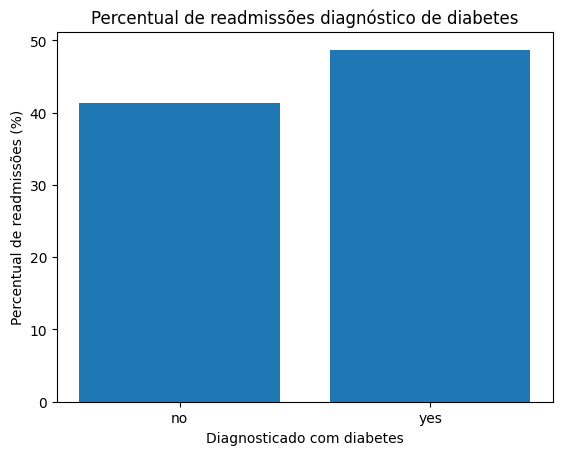

In [42]:
teste_diabetes = df.groupby(['diabetes_med'])['readmitted'].value_counts().unstack().fillna(0)
percentual_diabetes = teste_diabetes.div(teste_diabetes.sum(axis=1), axis=0) * 100
teste_diabetes
percentual_diabetes
x = teste_diabetes.index
y = percentual_diabetes.yes
plt.bar(x, y)
plt.title('Percentual de readmissões diagnóstico de diabetes')
plt.xlabel('Diagnosticado com diabetes')
plt.ylabel('Percentual de readmissões (%)')
plt.show()

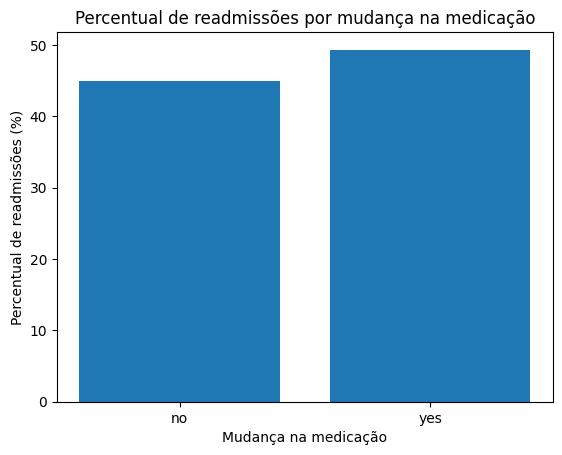

In [43]:
mudanca_medicamentos = df.groupby(['change'])['readmitted'].value_counts().unstack().fillna(0)
percentual_change = mudanca_medicamentos.div(mudanca_medicamentos.sum(axis=1), axis=0) * 100
mudanca_medicamentos
percentual_change
x = mudanca_medicamentos.index
y = percentual_change.yes
plt.bar(x, y)
plt.title('Percentual de readmissões por mudança na medicação')
plt.xlabel('Mudança na medicação')
plt.ylabel('Percentual de readmissões (%)')
plt.show()

# Resultados observados:
A1Ctest
Pacientes com A1C elevado apresentaram taxa de readmissão um pouco superior aos pacientes com A1C normal.
A associação observada foi fraca:
glucose_test

Pacientes com glicose elevada apresentaram maior taxa de readmissão.
A associação observada foi moderada:
diabetes_med

Pacientes que utilizavam medicação para diabetes apresentaram taxa de readmissão superior aos pacientes sem medicação.

A associação observada foi moderada:
change

Pacientes que tiveram alteração no tratamento apresentaram taxa de readmissão um pouco superior.
A associação observada foi fraca a moderada.

# Hipótese 5: O diagnóstico principal do paciente está associado à probabilidade de readmissão hospitalar


Quais os diagnósticos em diag_1: readmitted         no   yes
diag_1                     
Circulatory      4074  3750
Diabetes          810   937
Digestive        1224  1105
Injury            939   727
Missing             2     2
Musculoskeletal   757   495
Other            3566  2932
Respiratory      1874  1806
Numero total de pacientes: readmitted
no     13246
yes    11754
dtype: int64


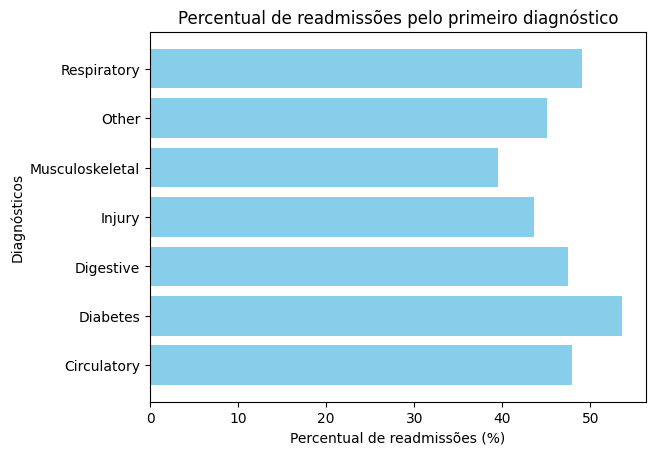

In [44]:
diagnosticos = df.groupby(['diag_1'])['readmitted'].value_counts().unstack().fillna(0)
percentual = diagnosticos.div(diagnosticos.sum(axis=1), axis=0) * 100
print(f'Quais os diagnósticos em diag_1: {diagnosticos}')
print(f'Numero total de pacientes: {diagnosticos.sum()}')
percentual
diagnosticos = diagnosticos.drop('Missing')
percentual = percentual.drop('Missing')
categorias = diagnosticos.index
valores = percentual.yes
plt.barh(categorias, valores, color='skyblue')
plt.title('Percentual de readmissões pelo primeiro diagnóstico')
plt.xlabel('Percentual de readmissões (%)')
plt.ylabel('Diagnósticos')
plt.show()

# Resultados observados:
- Pacientes com diagnóstico principal relacionado a Diabetes apresentaram a maior taxa de readmissão (53,6%).
- Doenças Respiratórias apresentaram a segunda maior taxa de readmissão (49,1%).
- Diagnósticos Musculoesqueléticos apresentaram a menor taxa observada (39,5%).
Conclusão preliminar:
Os resultados sugerem que o tipo de doença principal está associado à probabilidade de readmissão hospitalar. Entre os diagnósticos analisados, Diabetes apresentou a associação mais forte com a ocorrência de novas internações.

# Hipótese 6: Pacientes com maior utilização prévia do sistema de saúde apresentam maior probabilidade de readmissão.


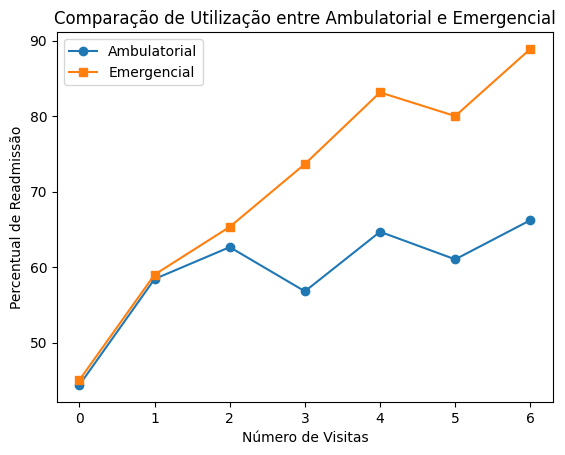

In [45]:
utilizacao_ambulatorial = df.groupby('n_outpatient')['readmitted'].value_counts().unstack().fillna(0)
percentual_ambulatorial = utilizacao_ambulatorial.div(utilizacao_ambulatorial.sum(axis=1), axis=0) * 100
utilizacao_ambulatorial
percentual_ambulatorial
utilizacao_emergencial = df.groupby('n_emergency')['readmitted'].value_counts().unstack().fillna(0)
percentual_emergencial = utilizacao_emergencial.div(utilizacao_emergencial.sum(axis=1), axis=0) * 100
utilizacao_emergencial
percentual_emergencial
utilizacao_ambulatorial_filtrada = utilizacao_ambulatorial[utilizacao_ambulatorial.index < 7]
utilizacao_emergencial_filtrada = utilizacao_emergencial[utilizacao_emergencial.index < 7]
percentual_ambulatorial_filtrada = percentual_ambulatorial.loc[percentual_ambulatorial.index < 7]
percentual_emergencial_filtrada = percentual_emergencial.loc[percentual_emergencial.index < 7]
x = utilizacao_ambulatorial_filtrada.index
x2 = utilizacao_emergencial_filtrada.index
y = percentual_ambulatorial_filtrada.yes
y2 = percentual_emergencial_filtrada.yes
plt.plot(x, y, marker='o', label='Ambulatorial')
plt.plot(x2, y2, marker='s', label='Emergencial')
plt.xlabel('Número de Visitas')
plt.ylabel('Percentual de Readmissão')
plt.title('Comparação de Utilização entre Ambulatorial e Emergencial')
plt.legend()
plt.show()


# Resultados observados:
Pacientes com histórico de utilização prévia do sistema de saúde apresentaram maior probabilidade de readmissão hospitalar. A relação foi observada tanto para atendimentos ambulatoriais quanto para atendimentos emergenciais. Entretanto, o crescimento da taxa de readmissão foi significativamente mais acentuado para pacientes com histórico de visitas emergenciais, sugerindo que essa variável pode representar um forte indicador de gravidade clínica ou instabilidade do quadro de saúde.

# Hipótese 7: Pacientes mais idosos apresentam maior probabilidade de readmissão?

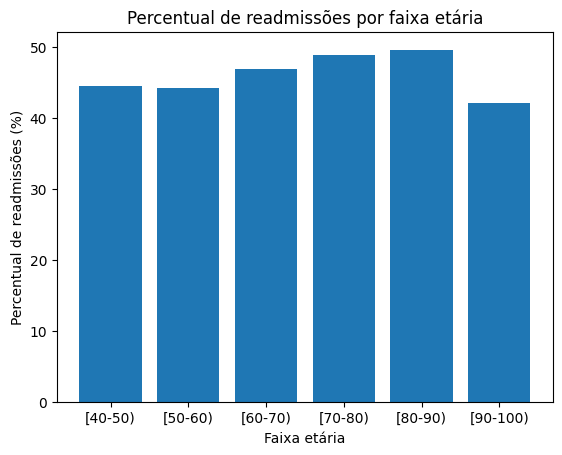

In [46]:
idade = df.groupby('age')['readmitted'].value_counts().unstack().fillna(0)
percentual_idade = idade.div(idade.sum(axis=1), axis=0) * 100
idade
percentual_idade
x = idade.index
y = percentual_idade.yes
plt.bar(x, y)
plt.title('Percentual de readmissões por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Percentual de readmissões (%)')
plt.show()

# Resultados observados:

A taxa de readmissão apresentou tendência crescente entre as faixas etárias de 40-50 e 80-90 anos.
O maior percentual observado ocorreu entre pacientes de 80-90 anos.
Na faixa de 90-100 anos foi observada uma redução da taxa de readmissão.

# Possíveis explicações:

viés de sobrevivência;
diferenças no perfil clínico dos pacientes muito idosos;
eventos concorrentes não registrados no dataset (como óbito ou cuidados paliativos);
limitações inerentes à construção do conjunto de dados.

# Conclusão preliminar:

Os resultados sugerem que a idade está associada à probabilidade de readmissão, porém a redução observada na faixa de 90-100 anos requer investigação adicional e não pode ser interpretada isoladamente como menor risco clínico.

# Principais descobertas da análise exploratória:

1. O histórico de internações anteriores (n_inpatient) apresentou a associação mais forte com a readmissão hospitalar.

2. Pacientes com diagnóstico principal relacionado a Diabetes apresentaram a maior taxa de readmissão entre os grupos diagnósticos analisados.

3. O tempo de internação apresentou associação positiva com a readmissão, especialmente entre 7 e 10 dias.

4. Pacientes submetidos a maior quantidade de medicamentos apresentaram tendência de maior readmissão.

5. Indicadores relacionados ao diabetes demonstraram associação positiva, porém mais fraca do que variáveis relacionadas ao histórico hospitalar.
